# 01 - MS-ASL EDA

Initial exploration of the MS-ASL dataset.
Notebook focuses only on EDA for MS-ASL train/val/test splits.

In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [5]:
PROJECT_ROOT = Path.cwd().resolve().parent.parent if Path.cwd().name == 'MS-ASL_EDA' else (Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve())
MSASL_DIR = PROJECT_ROOT / 'MS-ASL'
TRAIN_JSON = MSASL_DIR / 'MSASL_train.json'
VAL_JSON = MSASL_DIR / 'MSASL_val.json'
TEST_JSON = MSASL_DIR / 'MSASL_test.json'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('MSASL_DIR exists:', MSASL_DIR.exists())
print('TRAIN_JSON exists:', TRAIN_JSON.exists())
print('VAL_JSON exists:', VAL_JSON.exists())
print('TEST_JSON exists:', TEST_JSON.exists())

PROJECT_ROOT: C:\Users\kacpe\source\repos\szum
MSASL_DIR exists: True
TRAIN_JSON exists: True
VAL_JSON exists: True
TEST_JSON exists: True


In [6]:
def load_split(path: Path, split_name: str) -> pd.DataFrame:
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df['split'] = split_name
    return df

df_train = load_split(TRAIN_JSON, 'train')
df_val = load_split(VAL_JSON, 'val')
df_test = load_split(TEST_JSON, 'test')

df_msasl = pd.concat([df_train, df_val, df_test], ignore_index=True)

print('Rows train:', len(df_train))
print('Rows val:', len(df_val))
print('Rows test:', len(df_test))
print('Rows total:', len(df_msasl))
print('Columns:', sorted(df_msasl.columns.tolist()))
df_msasl.head()

Rows train: 16054
Rows val: 5287
Rows test: 4172
Rows total: 25513
Columns: ['box', 'clean_text', 'end', 'end_time', 'file', 'fps', 'height', 'label', 'org_text', 'review', 'signer', 'signer_id', 'split', 'start', 'start_time', 'text', 'url', 'width']


,org_text,clean_text,start_time,signer_id,signer,start,end,file,label,height,fps,end_time,url,text,box,width,review,split
0,match [light-a-MATCH],match,0.0,0,0,0,83,match light-a-MATCH,830,360.0,30.00,2.767,https://www.youtube.com/watch?v=C37R_Ix8-qs,match,"[0.05754461884498596, 0.21637457609176636, 1.0...",640.0,NaN,train
1,FAIL,fail,0.0,0,-1,0,74,FAIL,542,360.0,25.00,2.960,https://www.youtube.com/watch?v=PIsUJl8BN_I,fail,"[0.0657794177532196, 0.16717177629470825, 0.93...",480.0,NaN,train
2,laugh,laugh,0.0,4,26,0,31,SignSchool Laugh with Legs 2,312,360.0,29.97,1.034,www.youtube.com/watch?v=9FdHlMOnVjg,laugh,"[0.13188594579696655, 0.32334136962890625, 1.0...",640.0,NaN,train
3,BOOK,book,0.0,0,-1,0,66,BOOK(3),38,360.0,25.00,2.640,https://www.youtube.com/watch?v=J7tP98oDxqE,book,"[0.05569887161254883, 0.25173279643058777, 0.9...",480.0,NaN,train
4,sign-language,sign language,0.0,0,-1,0,75,SIGN-LANGUAGE-S-CLAW-F,848,360.0,29.97,2.502,www.youtube.com/watch?v=N2mG9ZKjrGA,sign language,"[0.03904399275779724, 0.24198183417320251, 1.0...",640.0,NaN,train


In [7]:
# use clean_text as the working label
df_msasl['label_text'] = df_msasl['clean_text'].astype(str).str.strip().str.lower()

print('Unique labels (clean_text):', df_msasl['label_text'].nunique())
print('Unique urls: ', df_msasl['url'].nunique())
print('Unique signer_id:', df_msasl['signer_id'].nunique(dropna=True))
print('Split distribution:')
display(df_msasl['split'].value_counts(dropna=False).to_frame('count'))

print('Top 20 labels:')
display(df_msasl['label_text'].value_counts().head(20).to_frame('count'))

Unique labels (clean_text): 1056
Unique urls:  7213
Unique signer_id: 222
Split distribution:


,count
split,
train,16054
val,5287
test,4172


Top 20 labels:


,count
label_text,
nice,85
teacher,77
eat,77
no,73
happy,72
like,71
orange,70
want,69
deaf,69


In [8]:
num_cols = ['start', 'end', 'start_time', 'end_time', 'fps', 'width', 'height']
for c in num_cols:
    if c in df_msasl.columns:
        df_msasl[c] = pd.to_numeric(df_msasl[c], errors='coerce')

df_msasl['length_frames'] = np.where(
    df_msasl['start'].notna() & df_msasl['end'].notna() & (df_msasl['end'] >= df_msasl['start']),
    df_msasl['end'] - df_msasl['start'] + 1,
    np.nan
)

df_msasl['duration_sec_meta'] = np.where(
    df_msasl['start_time'].notna() & df_msasl['end_time'].notna() & (df_msasl['end_time'] >= df_msasl['start_time']),
    df_msasl['end_time'] - df_msasl['start_time'],
    np.nan
)

print('Numeric stats:')
display(df_msasl[['fps', 'length_frames', 'duration_sec_meta', 'width', 'height']].describe().T)

Numeric stats:


,count,mean,std,min,25%,50%,75%,max
fps,25513.0,28.656305,2.833379,7.43,29.892,29.970,29.970,30.796
length_frames,25513.0,86.924000,40.257441,1.00,58.000,81.000,111.000,271.000
duration_sec_meta,25513.0,3.013772,1.410203,0.00,2.000,2.769,3.867,11.600
width,25513.0,785.101321,318.039337,202.00,640.000,640.000,1280.000,1280.000
height,25513.0,462.573120,166.049426,218.00,360.000,360.000,720.000,720.000


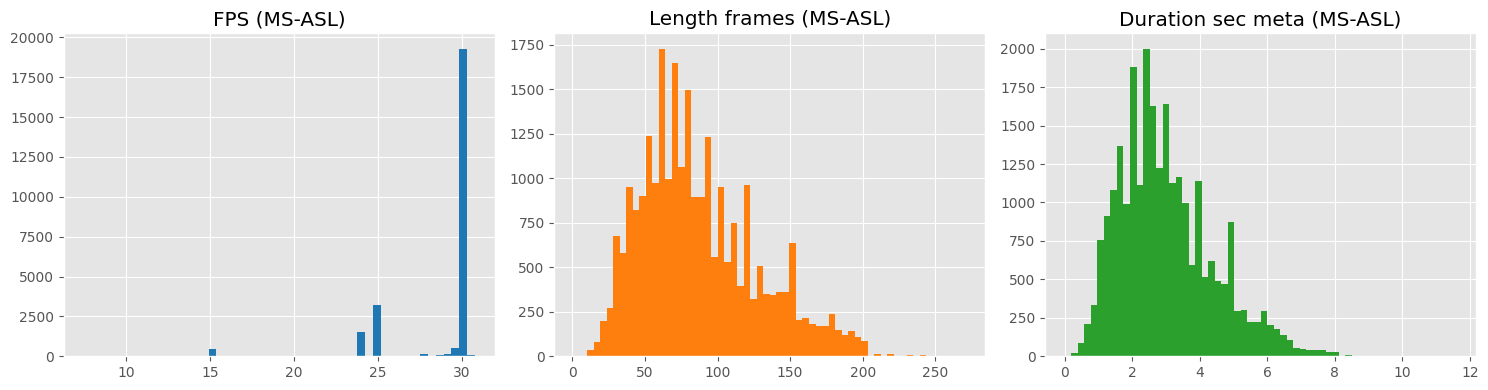

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_msasl['fps'].dropna().hist(bins=50, ax=axes[0], color='#1f77b4')
axes[0].set_title('FPS (MS-ASL)')

df_msasl['length_frames'].dropna().hist(bins=60, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Length frames (MS-ASL)')

df_msasl['duration_sec_meta'].dropna().hist(bins=60, ax=axes[2], color='#2ca02c')
axes[2].set_title('Duration sec meta (MS-ASL)')

plt.tight_layout()
plt.show()

In [ ]:
df_msasl['url_norm'] = df_msasl['url'].astype(str).str.strip().str.lower()

url_missing = (df_msasl['url_norm'] == '') | (df_msasl['url_norm'] == 'nan')
print('Missing/empty URL rows:', int(url_missing.sum()))

dup_key_cols = ['url_norm', 'start', 'end', 'label_text']
dup_mask = df_msasl.duplicated(subset=dup_key_cols, keep=False)
print('Potential duplicates (url+start+end+label):', int(dup_mask.sum()))

display(df_msasl.loc[dup_mask, dup_key_cols + ['split']].head(20))

Missing/empty URL rows: 0
Potential duplicates (url+start+end+label): 4


,url_norm,start,end,label_text,split
3458,www.youtube.com/watch?v=zdpx4ivagnm,0,106,graduate,train
4276,www.youtube.com/watch?v=c7962ndgirc,0,77,inform,train
4635,www.youtube.com/watch?v=c7962ndgirc,0,77,inform,train
10731,www.youtube.com/watch?v=zdpx4ivagnm,0,106,graduate,train


In [ ]:
label_counts = df_msasl['label_text'].value_counts()

print('Labels MS-ASL:', int(label_counts.size))
print('Min samples per label:', int(label_counts.min()))
print('Median samples per label:', float(label_counts.median()))
print('Max samples per label:', int(label_counts.max()))

print('Top 30 most frequent labels:')
display(label_counts.head(30).to_frame('count'))

print('Top 30 rarest labels:')
display(label_counts.sort_values().head(30).to_frame('count'))

Labels MS-ASL: 1056
Min samples per label: 1
Median samples per label: 20.0
Max samples per label: 85
Top 30 most frequent labels:


,count
label_text,
nice,85
teacher,77
eat,77
no,73
happy,72
like,71
orange,70
want,69
deaf,69


Top 30 rarest labels:


,count
label_text,
speed,1
ﬁre,1
give ticket,1
purchase,1
spell,1
#apt,1
give you,1
educate,1
ﬂoor,1
